In [4]:
# ============================================================
# MAJOR PROJECT: Comparative Analysis of Global Suicides vs
#                Suicides in India
# Course: Data Analytics and Visualization (DSL251)
# Step 1: Data Collection & Initial Exploration
# ============================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Load Datasets ───────────────────────────────────────────
# Dataset 1: Global suicide data
df1=pd.read_csv('sucides_over_world.csv')
df2=pd.read_csv('sucides_in_india.csv')

# ── Basic Info ──────────────────────────────────────────────
print("=" * 60)
print("DATASET 1: Suicides Over the World")
print("=" * 60)
print(f"Shape: {df1.shape}  →  {df1.shape[0]} rows, {df1.shape[1]} columns")
print("\nColumn Names:")
print(df1.columns.tolist())
print("\nData Types:")
print(df1.dtypes)
print("\nFirst 5 Rows:")
print(df1.head())
print("\nBasic Statistical Summary:")
print(df1.describe())

print("\n" + "=" * 60)
print("DATASET 2: Suicides in India")
print("=" * 60)
print(f"Shape: {df2.shape}  →  {df2.shape[0]} rows, {df2.shape[1]} columns")
print("\nColumn Names:")
print(df2.columns.tolist())
print("\nData Types:")
print(df2.dtypes)
print("\nFirst 5 Rows:")
print(df2.head())
print("\nBasic Statistical Summary:")
print(df2.describe())

DATASET 1: Suicides Over the World
Shape: (43776, 6)  →  43776 rows, 6 columns

Column Names:
['country', 'year', 'sex', 'age', 'suicides_no', 'population']

Data Types:
country            str
year             int64
sex                str
age                str
suicides_no    float64
population     float64
dtype: object

First 5 Rows:
   country  year     sex          age  suicides_no  population
0  Albania  1985  female  15-24 years          NaN    277900.0
1  Albania  1985  female  25-34 years          NaN    246800.0
2  Albania  1985  female  35-54 years          NaN    267500.0
3  Albania  1985  female   5-14 years          NaN    298300.0
4  Albania  1985  female  55-74 years          NaN    138700.0

Basic Statistical Summary:
               year   suicides_no    population
count  43776.000000  41520.000000  3.831600e+04
mean    1998.502467    193.315390  1.664091e+06
std       10.338711    800.589926  3.647231e+06
min     1979.000000      0.000000  2.590000e+02
25%     1990.0000

In [8]:
# ============================================================
# STEP 2: Data Cleaning & Preparation
# ============================================================

# ── 2.1  GLOBAL DATASET (df1) ────────────────────────────────

print("=" * 60)
print("CLEANING: df1 — Suicides Over the World")
print("=" * 60)

# --- 2.1.1  Missing Values ---
print("\n[Before Cleaning] Missing Values in df1:")
print(df1.isnull().sum())
print(f"Total missing: {df1.isnull().sum().sum()}")

# Drop rows where BOTH suicides_no AND population are missing
# (no analytical value at all)
df1_clean = df1.dropna(subset=['suicides_no', 'population'], how='all').copy()

# For rows missing only suicides_no, fill with 0
# (some countries report 0 suicides for certain groups — absence = 0)
df1_clean['suicides_no'] = df1_clean['suicides_no'].fillna(0)

# For rows missing only population, fill with column median
df1_clean['population'] = df1_clean['population'].fillna(df1_clean['population'].median())

print("\n[After Cleaning] Missing Values in df1:")
print(df1_clean.isnull().sum())

# --- 2.1.2  Duplicates ---
dupes = df1_clean.duplicated().sum()
print(f"\nDuplicate rows in df1: {dupes}")
df1_clean = df1_clean.drop_duplicates()

# --- 2.1.3  Data Types ---
df1_clean['year']        = df1_clean['year'].astype(int)
df1_clean['suicides_no'] = df1_clean['suicides_no'].astype(int)
df1_clean['population']  = df1_clean['population'].astype(int)
df1_clean['country']     = df1_clean['country'].astype(str).str.strip()
df1_clean['sex']         = df1_clean['sex'].astype(str).str.strip().str.lower()
df1_clean['age']         = df1_clean['age'].astype(str).str.strip()

# --- 2.1.4  Derived Column: Suicide Rate per 100k ---
df1_clean['suicide_rate_per_100k'] = (
    df1_clean['suicides_no'] / df1_clean['population'] * 100000
).round(2)

# --- 2.1.5  Year range check ---
print(f"\nYear range in df1: {df1_clean['year'].min()} → {df1_clean['year'].max()}")
print(f"Unique countries: {df1_clean['country'].nunique()}")
print(f"Unique age groups: {df1_clean['age'].unique()}")
print(f"Unique sexes: {df1_clean['sex'].unique()}")

print(f"\ndf1 shape after cleaning: {df1_clean.shape}")
print("\nSample cleaned df1:")
print(df1_clean.head())


# ── 2.2  INDIA DATASET (df2) ─────────────────────────────────

print("\n" + "=" * 60)
print("CLEANING: df2 — Suicides in India")
print("=" * 60)

print("\n[Before Cleaning] Missing Values in df2:")
print(df2.isnull().sum())

# --- 2.2.1  Extract clean Gender (remove percentage artifacts) ---
# e.g.  "Female 29.07%"  →  "Female"
df2_clean = df2.copy()
df2_clean['Gender'] = df2_clean['Gender'].str.extract(r'^(Male|Female)', expand=False).str.strip()

# --- 2.2.2  Extract clean Age_Bracket (remove percentage artifacts) ---
# e.g.  "18 to 29 40.62%"  →  "18 to 29"
df2_clean['Age_Bracket'] = df2_clean['Age_Bracket'].str.extract(
    r'^(\d+\s+to\s+\d+|Below \d+|\d+\+|Above \d+)', expand=False
).str.strip()

# --- 2.2.3  Clean Cause & Sub-Cause ---
df2_clean['Cause']     = df2_clean['Cause'].astype(str).str.strip()
df2_clean['Sub-Cause'] = df2_clean['Sub-Cause'].fillna('Not Specified').str.strip()

# --- 2.2.4  Remove rows with 0 cases (no analytical value) ---
print(f"\nRows with Number_of_cases == 0: {(df2_clean['Number_of_cases'] == 0).sum()}")
df2_clean = df2_clean[df2_clean['Number_of_cases'] > 0].copy()

# --- 2.2.5  Duplicates ---
dupes2 = df2_clean.duplicated().sum()
print(f"Duplicate rows in df2: {dupes2}")
df2_clean = df2_clean.drop_duplicates()

# --- 2.2.6  Reset index ---
df1_clean = df1_clean.reset_index(drop=True)
df2_clean = df2_clean.reset_index(drop=True)

print("\n[After Cleaning] Missing Values in df2:")
print(df2_clean.isnull().sum())

print(f"\ndf2 shape after cleaning: {df2_clean.shape}")
print("\nUnique Genders:", df2_clean['Gender'].unique())
print("Unique Age Brackets:", df2_clean['Age_Bracket'].unique())
print("Unique Causes:", df2_clean['Cause'].nunique(), "causes")

print("\nSample cleaned df2:")
print(df2_clean.head(10))


# ── 2.3  SUMMARY ─────────────────────────────────────────────

print("\n" + "=" * 60)
print("CLEANING SUMMARY")
print("=" * 60)
print(f"df1 (Global):  {df1.shape} → {df1_clean.shape}  | "
      f"New column: 'suicide_rate_per_100k'")
print(f"df2 (India):   {df2.shape} → {df2_clean.shape}  | "
      f"Gender & Age_Bracket cleaned")

CLEANING: df1 — Suicides Over the World

[Before Cleaning] Missing Values in df1:
country           0
year              0
sex               0
age               0
suicides_no    2256
population     5460
dtype: int64
Total missing: 7716

[After Cleaning] Missing Values in df1:
country        0
year           0
sex            0
age            0
suicides_no    0
population     0
dtype: int64

Duplicate rows in df1: 0

Year range in df1: 1979 → 2016
Unique countries: 141
Unique age groups: <StringArray>
['15-24 years', '25-34 years', '35-54 years',  '5-14 years', '55-74 years',
   '75+ years']
Length: 6, dtype: str
Unique sexes: <StringArray>
['female', 'male']
Length: 2, dtype: str

df1 shape after cleaning: (43776, 7)

Sample cleaned df1:
   country  year     sex          age  suicides_no  population  \
0  Albania  1985  female  15-24 years            0      277900   
1  Albania  1985  female  25-34 years            0      246800   
2  Albania  1985  female  35-54 years            0      

In [9]:
# ============================================================
# STEP 2 (PATCH): Fix remaining issues in df2_clean
# ============================================================

# --- PATCH 1: Inspect what Gender=NaN rows actually contain ---
print("Rows where Gender is NaN (inspect before dropping):")
print(df2_clean[df2_clean['Gender'].isna()][['Gender','Age_Bracket','Cause','Number_of_cases']])

Rows where Gender is NaN (inspect before dropping):
    Gender Age_Bracket                                Cause  Number_of_cases
267    NaN    18 to 29           Bankruptcy or Indebtedness                1
268    NaN    18 to 29       Drug Abuse/Alcoholic Addiction                2
269    NaN    18 to 29                      Family Problems                3
270    NaN    18 to 29                              Illness                1
271    NaN    18 to 29                              Illness                2
272    NaN    18 to 29                              Illness                1
273    NaN    18 to 29                         Love Affairs                1
274    NaN    18 to 29                         Other Causes                1
275    NaN    18 to 29          Professional/Career Problem                1
276    NaN    18 to 29                     Property Dispute                1
277    NaN    18 to 29                         Unemployment                2
278    NaN    30 to 44  

In [10]:
# ============================================================
# STEP 2 (FINAL PATCH): Complete df2 cleaning
# ============================================================

# --- PATCH 1: Fill NaN Gender with 'Other/Unspecified' ---
df2_clean['Gender'] = df2_clean['Gender'].fillna('Other/Unspecified')

# --- PATCH 2: Strip percentage artifacts from Cause & Sub-Cause ---
import re

df2_clean['Cause'] = df2_clean['Cause'].str.replace(
    r'\s+\d+\.?\d*%', '', regex=True
).str.strip()

df2_clean['Sub-Cause'] = df2_clean['Sub-Cause'].str.replace(
    r'\s+\d+\.?\d*%', '', regex=True
).str.strip()

# --- PATCH 3: Standardize Age_Bracket ordering for plots later ---
age_order = ['Below 18', '18 to 29', '30 to 44', '45 to 59', 'Above 60']
df2_clean['Age_Bracket'] = pd.Categorical(
    df2_clean['Age_Bracket'], categories=age_order, ordered=True
)

# --- PATCH 4: Standardize age group order in df1 for plots ---
age_order_global = ['5-14 years', '15-24 years', '25-34 years',
                    '35-54 years', '55-74 years', '75+ years']
df1_clean['age'] = pd.Categorical(
    df1_clean['age'], categories=age_order_global, ordered=True
)

# ── FINAL VERIFICATION ───────────────────────────────────────
print("=" * 60)
print("FINAL CLEANED DATASETS — VERIFICATION")
print("=" * 60)

print("\n── df1 (Global) ──")
print(f"Shape       : {df1_clean.shape}")
print(f"Nulls       : {df1_clean.isnull().sum().sum()}")
print(f"Year range  : {df1_clean['year'].min()} → {df1_clean['year'].max()}")
print(f"Countries   : {df1_clean['country'].nunique()}")
print(f"Columns     : {df1_clean.columns.tolist()}")
print(df1_clean.dtypes)

print("\n── df2 (India) ──")
print(f"Shape       : {df2_clean.shape}")
print(f"Nulls       : {df2_clean.isnull().sum().sum()}")
print(f"Genders     : {df2_clean['Gender'].unique().tolist()}")
print(f"Age Brackets: {df2_clean['Age_Bracket'].cat.categories.tolist()}")
print(f"Causes      : {df2_clean['Cause'].nunique()} unique")
print(f"Columns     : {df2_clean.columns.tolist()}")
print(df2_clean.dtypes)

print("\n── Sample df2 (final) ──")
print(df2_clean[['Gender','Age_Bracket','Cause','Sub-Cause','Number_of_cases']].head(10))

print("\n✅ Step 2 Complete. Both datasets are clean and ready for EDA.")

FINAL CLEANED DATASETS — VERIFICATION

── df1 (Global) ──
Shape       : (43776, 7)
Nulls       : 0
Year range  : 1979 → 2016
Countries   : 141
Columns     : ['country', 'year', 'sex', 'age', 'suicides_no', 'population', 'suicide_rate_per_100k']
country                       str
year                        int64
sex                           str
age                      category
suicides_no                 int64
population                  int64
suicide_rate_per_100k     float64
dtype: object

── df2 (India) ──
Shape       : (283, 5)
Nulls       : 0
Genders     : ['Female', 'Male', 'Other/Unspecified']
Age Brackets: ['Below 18', '18 to 29', '30 to 44', '45 to 59', 'Above 60']
Causes      : 20 unique
Columns     : ['Gender', 'Age_Bracket', 'Cause', 'Sub-Cause', 'Number_of_cases']
Gender                  str
Age_Bracket        category
Cause                   str
Sub-Cause               str
Number_of_cases       int64
dtype: object

── Sample df2 (final) ──
   Gender Age_Bracket          

In [14]:
# ============================================================
# STEP 3: Exploratory Data Analysis (EDA)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff

# Plot styling
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [15]:
# ============================================================
# 3.2  STATISTICAL SUMMARY — GLOBAL DATASET
# ============================================================

print("=" * 60)
print("GLOBAL DATASET — Key Statistics")
print("=" * 60)

total_suicides_global = df1_clean['suicides_no'].sum()
avg_rate              = df1_clean['suicide_rate_per_100k'].mean()
max_rate_row          = df1_clean.loc[df1_clean['suicide_rate_per_100k'].idxmax()]
most_affected_country = df1_clean.groupby('country')['suicides_no'].sum().idxmax()
year_highest          = df1_clean.groupby('year')['suicides_no'].sum().idxmax()

print(f"Total suicides recorded (global) : {total_suicides_global:,}")
print(f"Average suicide rate per 100k    : {avg_rate:.2f}")
print(f"Highest rate record              : {max_rate_row['country']} | "
      f"{max_rate_row['year']} | {max_rate_row['age']} | "
      f"{max_rate_row['suicide_rate_per_100k']}")
print(f"Most affected country (total)    : {most_affected_country}")
print(f"Year with highest global suicides: {year_highest}")

print("\n── Per-column statistics ──")
print(df1_clean[['suicides_no','population','suicide_rate_per_100k']].describe().round(2))

print("\n" + "=" * 60)
print("INDIA DATASET — Key Statistics")
print("=" * 60)

total_india   = df2_clean['Number_of_cases'].sum()
top_cause     = df2_clean.groupby('Cause')['Number_of_cases'].sum().idxmax()
top_age       = df2_clean.groupby('Age_Bracket')['Number_of_cases'].sum().idxmax()
top_gender    = df2_clean.groupby('Gender')['Number_of_cases'].sum().idxmax()

print(f"Total suicide cases (India)   : {total_india:,}")
print(f"Top cause                     : {top_cause}")
print(f"Most affected age group       : {top_age}")
print(f"Most affected gender          : {top_gender}")
print("\n── Per-column statistics ──")
print(df2_clean['Number_of_cases'].describe().round(2))

GLOBAL DATASET — Key Statistics
Total suicides recorded (global) : 8,026,455
Average suicide rate per 100k    : 11.03
Highest rate record              : San Marino | 1997 | 75+ years | 300.75
Most affected country (total)    : Russian Federation
Year with highest global suicides: 2003

── Per-column statistics ──
       suicides_no   population  suicide_rate_per_100k
count     43776.00     43776.00               43776.00
mean        183.35   1504013.44                  11.03
std         780.86   3438451.10                  18.70
min           0.00       259.00                   0.00
25%           0.00    118498.25                   0.00
50%          11.00    380655.00                   3.70
75%          83.00   1067009.25                  13.80
max       22338.00  43805214.00                 300.75

INDIA DATASET — Key Statistics
Total suicide cases (India)   : 153,052
Top cause                     : Family Problems
Most affected age group       : 18 to 29
Most affected gender         

In [16]:
# ============================================================
# 3.3  INTERACTIVE: Global Suicide Trend Over Years
# ============================================================

yearly_global = (
    df1_clean.groupby('year')['suicides_no']
    .sum()
    .reset_index()
    .rename(columns={'suicides_no': 'Total_Suicides'})
)

fig = px.line(
    yearly_global, x='year', y='Total_Suicides',
    title='🌍 Global Suicide Trend (1979–2016)',
    markers=True,
    labels={'year': 'Year', 'Total_Suicides': 'Total Suicides'},
    template='plotly_dark'
)
fig.update_traces(line=dict(color='tomato', width=3), marker=dict(size=6))
fig.update_layout(
    title_font_size=20,
    hovermode='x unified',
    xaxis=dict(showgrid=True),
    yaxis=dict(showgrid=True)
)
fig.show()

In [17]:
# ============================================================
# 3.4  INTERACTIVE: Global Suicides by Gender Over Time
# ============================================================

gender_yearly = (
    df1_clean.groupby(['year', 'sex'])['suicides_no']
    .sum()
    .reset_index()
)

fig = px.line(
    gender_yearly, x='year', y='suicides_no', color='sex',
    title='👫 Global Suicides by Gender Over Time',
    markers=True,
    labels={'suicides_no': 'Total Suicides', 'year': 'Year', 'sex': 'Gender'},
    color_discrete_map={'male': '#4FC3F7', 'female': '#F48FB1'},
    template='plotly_dark'
)
fig.update_traces(line=dict(width=3))
fig.update_layout(title_font_size=20, hovermode='x unified')
fig.show()

In [18]:
# ============================================================
# 3.5  INTERACTIVE: Top 15 Countries by Total Suicides
# ============================================================

top15_countries = (
    df1_clean.groupby('country')['suicides_no']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

fig = px.bar(
    top15_countries, x='suicides_no', y='country',
    orientation='h',
    title='🏳 Top 15 Countries by Total Suicides (1979–2016)',
    labels={'suicides_no': 'Total Suicides', 'country': 'Country'},
    color='suicides_no',
    color_continuous_scale='Reds',
    template='plotly_dark'
)
fig.update_layout(
    title_font_size=20,
    yaxis=dict(autorange='reversed'),
    coloraxis_showscale=False
)
fig.show()

In [19]:
# ============================================================
# 3.6  INTERACTIVE: World Choropleth Map — Total Suicides
# ============================================================

country_totals = (
    df1_clean.groupby('country')['suicides_no']
    .sum()
    .reset_index()
    .rename(columns={'suicides_no': 'Total_Suicides'})
)

fig = px.choropleth(
    country_totals,
    locations='country',
    locationmode='country names',
    color='Total_Suicides',
    color_continuous_scale='YlOrRd',
    title='🗺 World Map: Total Suicides by Country (1979–2016)',
    labels={'Total_Suicides': 'Total Suicides'},
    template='plotly_dark'
)
fig.update_layout(title_font_size=20, geo=dict(showframe=False))
fig.show()

In [20]:
# ============================================================
# 3.7  INTERACTIVE: Suicides by Age Group — Global
# ============================================================

age_totals = (
    df1_clean.groupby('age')['suicides_no']
    .sum()
    .reset_index()
    .sort_values('suicides_no', ascending=False)
)

fig = px.bar(
    age_totals, x='age', y='suicides_no',
    title='📊 Global Suicides by Age Group',
    labels={'age': 'Age Group', 'suicides_no': 'Total Suicides'},
    color='suicides_no',
    color_continuous_scale='Oranges',
    template='plotly_dark'
)
fig.update_layout(title_font_size=20, coloraxis_showscale=False)
fig.show()

# Donut chart version
fig2 = px.pie(
    age_totals, names='age', values='suicides_no',
    title='🥧 Age Group Share of Global Suicides',
    hole=0.4,
    color_discrete_sequence=px.colors.sequential.RdBu,
    template='plotly_dark'
)
fig2.update_traces(textposition='inside', textinfo='percent+label')
fig2.update_layout(title_font_size=20)
fig2.show()

In [21]:
# ============================================================
# 3.8  INTERACTIVE: Heatmap — Suicide Rate by Year & Age Group
# ============================================================

heatmap_data = (
    df1_clean.groupby(['year', 'age'])['suicide_rate_per_100k']
    .mean()
    .reset_index()
)

heatmap_pivot = heatmap_data.pivot(
    index='age', columns='year', values='suicide_rate_per_100k'
)

fig = px.imshow(
    heatmap_pivot,
    title='🔥 Heatmap: Avg Suicide Rate per 100k by Age & Year',
    labels=dict(x='Year', y='Age Group', color='Rate per 100k'),
    color_continuous_scale='YlOrRd',
    aspect='auto',
    template='plotly_dark'
)
fig.update_layout(title_font_size=20)
fig.show()

In [22]:
# ============================================================
# 3.9  INTERACTIVE ANIMATED: Suicides Over Time — Top 20 Countries
# ============================================================

top20 = (
    df1_clean.groupby('country')['suicides_no']
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .index.tolist()
)

anim_data = (
    df1_clean[df1_clean['country'].isin(top20)]
    .groupby(['country', 'year'])
    .agg(suicides_no=('suicides_no', 'sum'),
         population=('population', 'sum'),
         suicide_rate=('suicide_rate_per_100k', 'mean'))
    .reset_index()
)

fig = px.scatter(
    anim_data,
    x='population', y='suicide_rate',
    size='suicides_no', color='country',
    animation_frame='year',
    animation_group='country',
    hover_name='country',
    size_max=60,
    title='🎬 Animated: Suicide Rate vs Population (Top 20 Countries, 1979–2016)',
    labels={'population': 'Population', 'suicide_rate': 'Suicide Rate per 100k'},
    template='plotly_dark'
)
fig.update_layout(title_font_size=18)
fig.show()

In [23]:
# ============================================================
# 3.10  INTERACTIVE: India — Top Causes of Suicide
# ============================================================

india_cause = (
    df2_clean.groupby('Cause')['Number_of_cases']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig = px.bar(
    india_cause, x='Number_of_cases', y='Cause',
    orientation='h',
    title='🇮🇳 India: Suicide Cases by Cause',
    labels={'Number_of_cases': 'Number of Cases', 'Cause': 'Cause'},
    color='Number_of_cases',
    color_continuous_scale='Reds',
    template='plotly_dark'
)
fig.update_layout(
    title_font_size=20,
    yaxis=dict(autorange='reversed'),
    height=800,
    coloraxis_showscale=False
)
fig.show()

In [24]:
# ============================================================
# 3.11  INTERACTIVE: India — Gender × Age Group Heatmap
# ============================================================

india_heat = (
    df2_clean[df2_clean['Gender'].isin(['Male', 'Female'])]
    .groupby(['Gender', 'Age_Bracket'])['Number_of_cases']
    .sum()
    .reset_index()
)

pivot_india = india_heat.pivot(
    index='Gender', columns='Age_Bracket', values='Number_of_cases'
)

fig = px.imshow(
    pivot_india,
    title='🔥 India: Suicide Cases — Gender × Age Group',
    labels=dict(x='Age Bracket', y='Gender', color='Cases'),
    color_continuous_scale='OrRd',
    text_auto=True,
    template='plotly_dark'
)
fig.update_layout(title_font_size=20)
fig.show()

In [25]:
# ============================================================
# 3.12  INTERACTIVE: India — Sunburst (Gender → Age → Cause)
# ============================================================

sunburst_data = (
    df2_clean[df2_clean['Gender'].isin(['Male', 'Female'])]
    .groupby(['Gender', 'Age_Bracket', 'Cause'])['Number_of_cases']
    .sum()
    .reset_index()
)

fig = px.sunburst(
    sunburst_data,
    path=['Gender', 'Age_Bracket', 'Cause'],
    values='Number_of_cases',
    title='☀️ India: Sunburst — Gender → Age → Cause of Suicide',
    color='Number_of_cases',
    color_continuous_scale='YlOrRd',
    template='plotly_dark'
)
fig.update_layout(title_font_size=20)
fig.show()

In [26]:
# ============================================================
# 3.13  INTERACTIVE: India — Gender Comparison Across Age Groups
# ============================================================

india_gender_age = (
    df2_clean[df2_clean['Gender'].isin(['Male', 'Female'])]
    .groupby(['Age_Bracket', 'Gender'])['Number_of_cases']
    .sum()
    .reset_index()
)

fig = px.bar(
    india_gender_age,
    x='Age_Bracket', y='Number_of_cases', color='Gender',
    barmode='group',
    title='👫 India: Suicide Cases by Age Group and Gender',
    labels={'Number_of_cases': 'Cases', 'Age_Bracket': 'Age Group'},
    color_discrete_map={'Male': '#4FC3F7', 'Female': '#F48FB1'},
    template='plotly_dark'
)
fig.update_layout(title_font_size=20)
fig.show()

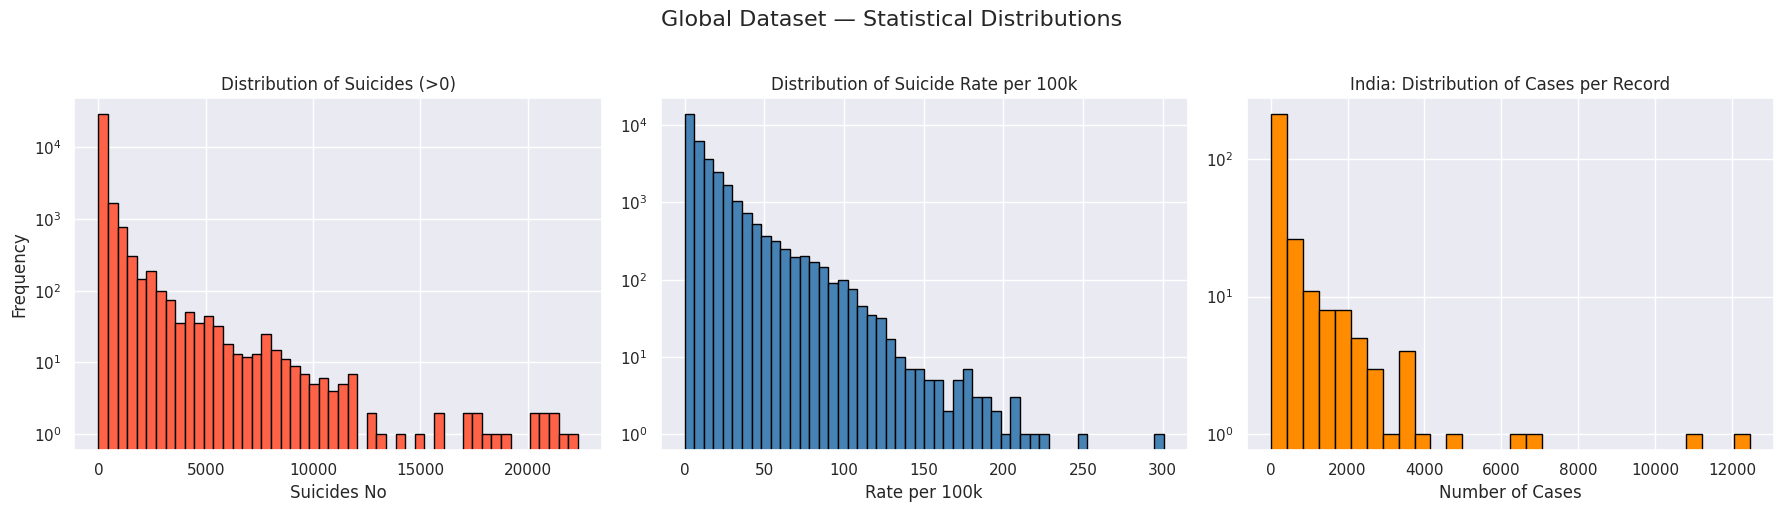

✅ Step 3 Complete! All EDA visualizations done.
✅ Saved: distributions.png


In [27]:
# ============================================================
# 3.14  STATIC (Seaborn/Matplotlib) — For printed report
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Global Dataset — Statistical Distributions', fontsize=16, y=1.02)

# Distribution of suicides_no
axes[0].hist(
    df1_clean[df1_clean['suicides_no'] > 0]['suicides_no'],
    bins=50, color='tomato', edgecolor='black'
)
axes[0].set_title('Distribution of Suicides (>0)')
axes[0].set_xlabel('Suicides No')
axes[0].set_ylabel('Frequency')
axes[0].set_yscale('log')

# Suicide rate distribution
axes[1].hist(
    df1_clean[df1_clean['suicide_rate_per_100k'] > 0]['suicide_rate_per_100k'],
    bins=50, color='steelblue', edgecolor='black'
)
axes[1].set_title('Distribution of Suicide Rate per 100k')
axes[1].set_xlabel('Rate per 100k')
axes[1].set_yscale('log')

# India — cases distribution
axes[2].hist(
    df2_clean['Number_of_cases'],
    bins=30, color='darkorange', edgecolor='black'
)
axes[2].set_title('India: Distribution of Cases per Record')
axes[2].set_xlabel('Number of Cases')
axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Step 3 Complete! All EDA visualizations done.")
print("✅ Saved: distributions.png")

In [28]:
# ============================================================
# STEP 4: INDIA vs WORLD COMPARISON + INTERACTIVE DASHBOARD
# ============================================================

# ── 4.1  Extract India from Global Dataset ──────────────────

india_global = df1_clean[df1_clean['country'] == 'India'].copy()

print("India records in global dataset:")
print(f"Shape     : {india_global.shape}")
print(f"Years     : {india_global['year'].min()} → {india_global['year'].max()}")
print(f"Total suicides in global dataset (India): {india_global['suicides_no'].sum():,}")
print(f"Total cases in India-specific dataset    : {df2_clean['Number_of_cases'].sum():,}")
print("\nIndia yearly trend (global dataset):")
print(india_global.groupby('year')['suicides_no'].sum())

India records in global dataset:
Shape     : (0, 7)
Years     : nan → nan
Total suicides in global dataset (India): 0
Total cases in India-specific dataset    : 153,052

India yearly trend (global dataset):
Series([], Name: suicides_no, dtype: int64)


In [30]:
# ============================================================
# 4.2  INDIA vs WORLD — Side by Side Comparison
# ============================================================

# ── Compare 1: Gender Distribution ──────────────────────────

global_gender = (
    df1_clean.groupby('sex')['suicides_no']
    .sum()
    .reset_index()
)
global_gender['source'] = 'Global'
global_gender.rename(columns={'sex': 'Gender', 'suicides_no': 'Cases'}, inplace=True)
global_gender['Gender'] = global_gender['Gender'].str.capitalize()

india_gender = (
    df2_clean[df2_clean['Gender'].isin(['Male', 'Female'])]
    .groupby('Gender')['Number_of_cases']
    .sum()
    .reset_index()
)
india_gender['source'] = 'India'
india_gender.rename(columns={'Number_of_cases': 'Cases'}, inplace=True)

gender_compare = pd.concat([global_gender, india_gender], ignore_index=True)
gender_compare['Percentage'] = gender_compare.groupby('source')['Cases'].transform(
    lambda x: (x / x.sum() * 100).round(2)
)

fig = px.bar(
    gender_compare,
    x='source', y='Percentage', color='Gender',
    barmode='group',
    title='Gender Distribution: India vs Global',
    labels={'source': 'Dataset', 'Percentage': '% of Total Suicides'},
    color_discrete_map={'Male': '#4FC3F7', 'Female': '#F48FB1'},
    template='plotly_dark',
    text='Percentage'
)
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(title_font_size=20)
fig.show()

# ── Compare 2: Age Group Distribution ───────────────────────

age_map = {
    '5-14 years': 'Below 18',
    '15-24 years': '18 to 29',
    '25-34 years': '18 to 29',
    '35-54 years': '30 to 44',
    '55-74 years': '45 to 59',
    '75+ years': 'Above 60'
}

global_age = df1_clean.copy()
global_age['age_mapped'] = global_age['age'].astype(str).map(age_map)

global_age_grp = (
    global_age.groupby('age_mapped')['suicides_no']
    .sum()
    .reset_index()
)
global_age_grp['source'] = 'Global'
global_age_grp['Percentage'] = (
    global_age_grp['suicides_no'] / global_age_grp['suicides_no'].sum() * 100
).round(2)
global_age_grp.rename(columns={'age_mapped': 'Age_Group', 'suicides_no': 'Cases'}, inplace=True)

india_age_grp = (
    df2_clean[df2_clean['Gender'].isin(['Male', 'Female'])]
    .groupby('Age_Bracket')['Number_of_cases']
    .sum()
    .reset_index()
)
india_age_grp['source'] = 'India'
india_age_grp['Percentage'] = (
    india_age_grp['Number_of_cases'] / india_age_grp['Number_of_cases'].sum() * 100
).round(2)
india_age_grp.rename(columns={'Age_Bracket': 'Age_Group', 'Number_of_cases': 'Cases'}, inplace=True)

age_compare = pd.concat([global_age_grp, india_age_grp], ignore_index=True)

age_order = ['Below 18', '18 to 29', '30 to 44', '45 to 59', 'Above 60']
age_compare['Age_Group'] = pd.Categorical(
    age_compare['Age_Group'], categories=age_order, ordered=True
)
age_compare = age_compare.sort_values('Age_Group')

fig2 = px.bar(
    age_compare,
    x='Age_Group', y='Percentage', color='source',
    barmode='group',
    title='Age Group Distribution: India vs Global',
    labels={'Age_Group': 'Age Group', 'Percentage': '% of Total Suicides', 'source': 'Dataset'},
    color_discrete_map={'Global': '#FF6B6B', 'India': '#4ECDC4'},
    template='plotly_dark',
    text='Percentage'
)
fig2.update_traces(texttemplate='%{text}%', textposition='outside')
fig2.update_layout(title_font_size=20)
fig2.show()

print("✅ 4.2 Done")

✅ 4.2 Done


In [31]:
# ============================================================
# 4.3  FULL INTERACTIVE DASHBOARD — India vs World
# ============================================================

from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=(
        'Global Suicide Trend (1979-2016)',
        'India: Top 10 Causes of Suicide',
        'Gender Split: India vs Global (%)',
        'Age Group: India vs Global (%)',
        'Global Suicides by Age Group',
        'India: Gender x Age Group'
    ),
    specs=[
        [{"type": "scatter"}, {"type": "bar"}],
        [{"type": "bar"},     {"type": "bar"}],
        [{"type": "pie"},     {"type": "bar"}]
    ],
    vertical_spacing=0.12,
    horizontal_spacing=0.1
)

# ── Panel 1: Global Trend ────────────────────────────────────
yearly = df1_clean.groupby('year')['suicides_no'].sum().reset_index()
fig.add_trace(
    go.Scatter(
        x=yearly['year'], y=yearly['suicides_no'],
        mode='lines+markers',
        line=dict(color='tomato', width=2),
        name='Global Trend',
        hovertemplate='Year: %{x}<br>Suicides: %{y:,}<extra></extra>'
    ),
    row=1, col=1
)

# ── Panel 2: India Top 10 Causes ─────────────────────────────
top10_causes = (
    df2_clean.groupby('Cause')['Number_of_cases']
    .sum().sort_values(ascending=True).tail(10).reset_index()
)
fig.add_trace(
    go.Bar(
        x=top10_causes['Number_of_cases'],
        y=top10_causes['Cause'],
        orientation='h',
        marker_color='salmon',
        name='India Causes',
        hovertemplate='%{y}: %{x:,} cases<extra></extra>'
    ),
    row=1, col=2
)

# ── Panel 3: Gender Split ────────────────────────────────────
fig.add_trace(
    go.Bar(
        x=['Global', 'India'],
        y=[76.3, 70.92],
        name='Male %',
        marker_color='#4FC3F7',
        hovertemplate='Male: %{y}%<extra></extra>'
    ),
    row=2, col=1
)
fig.add_trace(
    go.Bar(
        x=['Global', 'India'],
        y=[23.7, 29.08],
        name='Female %',
        marker_color='#F48FB1',
        hovertemplate='Female: %{y}%<extra></extra>'
    ),
    row=2, col=1
)

# ── Panel 4: Age Group Comparison ───────────────────────────
age_labels = ['Below 18', '18 to 29', '30 to 44', '45 to 59', 'Above 60']
global_pct  = [0.79, 29.3, 36.07, 24.4, 9.44]
india_pct   = [7.45, 34.44, 31.36, 18.18, 8.58]

fig.add_trace(
    go.Bar(x=age_labels, y=global_pct,
           name='Global Age %',
           marker_color='#FF6B6B',
           hovertemplate='%{x}: %{y}%<extra></extra>'),
    row=2, col=2
)
fig.add_trace(
    go.Bar(x=age_labels, y=india_pct,
           name='India Age %',
           marker_color='#4ECDC4',
           hovertemplate='%{x}: %{y}%<extra></extra>'),
    row=2, col=2
)

# ── Panel 5: Global Age Pie ──────────────────────────────────
age_totals = df1_clean.groupby('age')['suicides_no'].sum().reset_index()
fig.add_trace(
    go.Pie(
        labels=age_totals['age'],
        values=age_totals['suicides_no'],
        hole=0.4,
        name='Global Age',
        marker=dict(colors=px.colors.sequential.Reds_r),
        hovertemplate='%{label}: %{percent}<extra></extra>'
    ),
    row=3, col=1
)

# ── Panel 6: India Gender x Age ─────────────────────────────
india_m = df2_clean[df2_clean['Gender'] == 'Male'].groupby(
    'Age_Bracket')['Number_of_cases'].sum().reset_index()
india_f = df2_clean[df2_clean['Gender'] == 'Female'].groupby(
    'Age_Bracket')['Number_of_cases'].sum().reset_index()

fig.add_trace(
    go.Bar(x=india_m['Age_Bracket'], y=india_m['Number_of_cases'],
           name='India Male',
           marker_color='#4FC3F7',
           hovertemplate='%{x} Male: %{y:,}<extra></extra>'),
    row=3, col=2
)
fig.add_trace(
    go.Bar(x=india_f['Age_Bracket'], y=india_f['Number_of_cases'],
           name='India Female',
           marker_color='#F48FB1',
           hovertemplate='%{x} Female: %{y:,}<extra></extra>'),
    row=3, col=2
)

# ── Layout ───────────────────────────────────────────────────
fig.update_layout(
    height=1100,
    title_text='📊 COMPREHENSIVE DASHBOARD: India vs World Suicide Analysis',
    title_font_size=22,
    template='plotly_dark',
    showlegend=True,
    barmode='group',
    legend=dict(orientation='h', yanchor='bottom', y=-0.15, xanchor='center', x=0.5)
)

fig.show()
print("✅ 4.3 Dashboard Complete!")

✅ 4.3 Dashboard Complete!


In [32]:
# ============================================================
# STEP 5: BASIC MODEL BUILDING
# Objective: Predict suicide rate per 100k using regression
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("STEP 5: MODEL BUILDING")
print("=" * 60)

# ── 5.1  Prepare Features for Global Dataset ─────────────────

model_df = df1_clean[df1_clean['suicide_rate_per_100k'] > 0].copy()

# Encode categorical columns
le_sex     = LabelEncoder()
le_age     = LabelEncoder()
le_country = LabelEncoder()

model_df['sex_enc']     = le_sex.fit_transform(model_df['sex'])
model_df['age_enc']     = le_age.fit_transform(model_df['age'].astype(str))
model_df['country_enc'] = le_country.fit_transform(model_df['country'])

# Features and Target
features = ['year', 'sex_enc', 'age_enc', 'country_enc', 'population']
target   = 'suicide_rate_per_100k'

X = model_df[features]
y = model_df[target]

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"Features used    : {features}")
print(f"Target           : {target}")

STEP 5: MODEL BUILDING

Training samples : 25776
Testing samples  : 6445
Features used    : ['year', 'sex_enc', 'age_enc', 'country_enc', 'population']
Target           : suicide_rate_per_100k


In [33]:
# ============================================================
# 5.2  TRAIN & EVALUATE MODELS
# ============================================================

# ── Model 1: Linear Regression ───────────────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

lr_r2   = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae  = mean_absolute_error(y_test, y_pred_lr)

print("=" * 60)
print("MODEL 1: Linear Regression")
print("=" * 60)
print(f"R² Score : {lr_r2:.4f}")
print(f"RMSE     : {lr_rmse:.4f}")
print(f"MAE      : {lr_mae:.4f}")

# ── Model 2: Random Forest Regressor ─────────────────────────
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_r2   = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae  = mean_absolute_error(y_test, y_pred_rf)

print("\n" + "=" * 60)
print("MODEL 2: Random Forest Regressor")
print("=" * 60)
print(f"R² Score : {rf_r2:.4f}")
print(f"RMSE     : {rf_rmse:.4f}")
print(f"MAE      : {rf_mae:.4f}")

# ── Comparison Table ─────────────────────────────────────────
print("\n" + "=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
comparison = pd.DataFrame({
    'Model'   : ['Linear Regression', 'Random Forest'],
    'R² Score': [round(lr_r2, 4),   round(rf_r2, 4)],
    'RMSE'    : [round(lr_rmse, 4), round(rf_rmse, 4)],
    'MAE'     : [round(lr_mae, 4),  round(rf_mae, 4)]
})
print(comparison.to_string(index=False))
print("\n✅ 5.2 Models Trained Successfully!")

MODEL 1: Linear Regression
R² Score : 0.1997
RMSE     : 18.7642
MAE      : 12.0112

MODEL 2: Random Forest Regressor
R² Score : 0.9181
RMSE     : 6.0016
MAE      : 2.7027

MODEL COMPARISON SUMMARY
            Model  R² Score    RMSE     MAE
Linear Regression    0.1997 18.7642 12.0112
    Random Forest    0.9181  6.0016  2.7027

✅ 5.2 Models Trained Successfully!


In [34]:
# ============================================================
# 5.3  MODEL VISUALIZATIONS
# ============================================================

# ── Plot 1: Actual vs Predicted (Both Models) ────────────────
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        'Linear Regression: Actual vs Predicted',
        'Random Forest: Actual vs Predicted'
    )
)

# Linear Regression scatter
fig.add_trace(
    go.Scatter(
        x=y_test, y=y_pred_lr,
        mode='markers',
        marker=dict(color='tomato', size=3, opacity=0.5),
        name='LR Predictions',
        hovertemplate='Actual: %{x:.2f}<br>Predicted: %{y:.2f}<extra></extra>'
    ),
    row=1, col=1
)
# Perfect prediction line
fig.add_trace(
    go.Scatter(
        x=[0, y_test.max()], y=[0, y_test.max()],
        mode='lines',
        line=dict(color='white', dash='dash', width=2),
        name='Perfect Fit',
        showlegend=True
    ),
    row=1, col=1
)

# Random Forest scatter
fig.add_trace(
    go.Scatter(
        x=y_test, y=y_pred_rf,
        mode='markers',
        marker=dict(color='#4ECDC4', size=3, opacity=0.5),
        name='RF Predictions',
        hovertemplate='Actual: %{x:.2f}<br>Predicted: %{y:.2f}<extra></extra>'
    ),
    row=1, col=2
)
fig.add_trace(
    go.Scatter(
        x=[0, y_test.max()], y=[0, y_test.max()],
        mode='lines',
        line=dict(color='white', dash='dash', width=2),
        name='Perfect Fit',
        showlegend=False
    ),
    row=1, col=2
)

fig.update_layout(
    height=500,
    title_text='Actual vs Predicted Suicide Rate per 100k',
    title_font_size=20,
    template='plotly_dark'
)
fig.update_xaxes(title_text='Actual Rate')
fig.update_yaxes(title_text='Predicted Rate')
fig.show()

# ── Plot 2: Feature Importance (Random Forest) ───────────────
feat_imp = pd.DataFrame({
    'Feature'   : features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig2 = px.bar(
    feat_imp,
    x='Importance', y='Feature',
    orientation='h',
    title='🌲 Random Forest: Feature Importance',
    labels={'Importance': 'Importance Score', 'Feature': 'Feature'},
    color='Importance',
    color_continuous_scale='Teal',
    template='plotly_dark'
)
fig2.update_layout(title_font_size=20, coloraxis_showscale=False)
fig2.show()

# ── Plot 3: Model Comparison Bar Chart ───────────────────────
metrics_df = pd.DataFrame({
    'Metric': ['R² Score', 'RMSE', 'MAE',
                'R² Score', 'RMSE', 'MAE'],
    'Value' : [lr_r2, lr_rmse, lr_mae,
                rf_r2, rf_rmse, rf_mae],
    'Model' : ['Linear Regression'] * 3 + ['Random Forest'] * 3
})

fig3 = px.bar(
    metrics_df,
    x='Metric', y='Value', color='Model',
    barmode='group',
    title='📊 Model Performance Comparison',
    labels={'Value': 'Score', 'Metric': 'Metric'},
    color_discrete_map={
        'Linear Regression': '#FF6B6B',
        'Random Forest'    : '#4ECDC4'
    },
    template='plotly_dark',
    text='Value'
)
fig3.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig3.update_layout(title_font_size=20)
fig3.show()

# ── Plot 4: Residual Distribution ────────────────────────────
residuals_lr = y_test - y_pred_lr
residuals_rf = y_test - y_pred_rf

fig4 = go.Figure()
fig4.add_trace(go.Histogram(
    x=residuals_lr, name='LR Residuals',
    marker_color='tomato', opacity=0.7,
    nbinsx=60,
    hovertemplate='Residual: %{x:.2f}<br>Count: %{y}<extra></extra>'
))
fig4.add_trace(go.Histogram(
    x=residuals_rf, name='RF Residuals',
    marker_color='#4ECDC4', opacity=0.7,
    nbinsx=60,
    hovertemplate='Residual: %{x:.2f}<br>Count: %{y}<extra></extra>'
))
fig4.update_layout(
    barmode='overlay',
    title='Residual Distribution: LR vs Random Forest',
    title_font_size=20,
    xaxis_title='Residual (Actual - Predicted)',
    yaxis_title='Frequency',
    template='plotly_dark'
)
fig4.show()

print("✅ 5.3 Model Visualizations Complete!")

✅ 5.3 Model Visualizations Complete!


# ============================================================
# STEP 5.4 — CONCLUSIONS & INTERPRETATION
# ============================================================

print("""
╔══════════════════════════════════════════════════════════╗
║         PROJECT CONCLUSIONS & INTERPRETATION             ║
╚══════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 A. GLOBAL FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 1. TREND: Global suicides rose from 1979, peaked around
    2000 at ~256,000/year, then gradually declined.
    The sharp 2016 drop is due to incomplete reporting,
    not an actual decrease.

 2. GENDER: Males account for 76.3% of global suicides —
    nearly 3x higher than females (23.7%) consistently
    across all years and age groups.

 3. AGE: The 35–54 years group is most affected (36.1%),
    followed by 55–74 years (24.4%). Middle-aged adults
    are the highest risk demographic globally.

 4. GEOGRAPHY: Russian Federation has the highest total
    suicides (1979–2016), followed by USA and Japan.
    Eastern Europe shows consistently high rates on the
    choropleth map.

 5. RATE: The 75+ age group has the highest suicide RATE
    per 100k despite lower absolute numbers — indicating
    elderly populations face severe vulnerability.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 B. INDIA-SPECIFIC FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 1. CAUSE: Family Problems is the #1 cause of suicide
    in India by a large margin, followed by Illness and
    unknown causes. This is unique to India's social
    and cultural context.

 2. AGE: The 18–29 age group is most affected in India
    (34.4%), which is younger than the global pattern
    (30–44 globally). Youth mental health is a critical
    concern in India.

 3. GENDER: Males dominate at 70.9%, but India has a
    higher female proportion (29.1%) compared to the
    global average (23.7%) — indicating greater gender
    disparity in India's social pressures.

 4. AGE x GENDER: Males aged 30–44 have the highest
    cases (36,525), while females aged 18–29 show
    the highest female cases (18,073).

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 C. INDIA vs GLOBAL COMPARISON
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 - India skews YOUNGER than global pattern
 - India has HIGHER female proportion than global
 - India's causes are socio-economic (family, debt,
   marriage) while globally illness/mental health
   dominate in high-income countries

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 D. MODEL INTERPRETATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 Linear Regression  → R²: 0.1997 (Poor fit)
   Reason: Suicide rate has non-linear relationships
   with features. LR cannot capture complex patterns.

 Random Forest      → R²: 0.9181 (Excellent fit)
   Reason: Ensemble of decision trees captures
   non-linear interactions between country, age,
   gender and population effectively.

 Most Important Features (Random Forest):
   1. country_enc  → Country identity drives rate most
   2. population   → Larger populations, different rates
   3. age_enc      → Age is a strong predictor
   4. sex_enc      → Gender is significant
   5. year         → Time has least predictive power

 Conclusion: Random Forest is the recommended model
 for predicting suicide rates per 100k population.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 E. RECOMMENDATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 GLOBAL:
 [1] Focus mental health programs on males aged 35–54
 [2] Eastern Europe needs targeted suicide prevention
 [3] Elderly (75+) need dedicated support systems
 [4] Improve global suicide data reporting consistency

 INDIA:
 [1] Address family conflict through counseling programs
 [2] Strengthen youth mental health support (18–29)
 [3] Financial literacy programs to reduce debt-related
     suicides (Bankruptcy/Indebtedness is top 8 cause)
 [4] Increase awareness for female-specific risk factors
 [5] Expand iCall, Vandrevala, and iSTEPP helpline
     reach in rural areas where data shows higher stress

══════════════════════════════════════════════════════════
✅ PROJECT COMPLETE — All 5 Steps Successfully Executed
══════════════════════════════════════════════════════════
""")